# Batched Inference-Time Benchmark for Composite DNA Decoders
### Per-sample latency and throughput vs. batch size — Bi-LSTM, KL, ML, Min-Distance

This notebook measures **wall-clock inference time** for the four decoders as a
function of batch size ($B \in \{1, 50, 100, 200, 500\}$), to characterise how
batch processing amortises the per-sample cost of the neural decoder.

**No trained weights are needed.** Inference latency is a property of the
architecture and the input shape, not of the learned parameter values — a
randomly-initialised Bi-LSTM has timing identical to a trained one. The
benchmark therefore runs on freshly-initialised models and synthetic input.

---

### What this measures, and how to read it honestly

The Bi-LSTM performs far more FLOPs per position than the position-wise
baselines, and batching does **not** make it *faster than* those baselines —
the baselines are pure tensor operations with no sequential dependency and
parallelise at least as well. This notebook is **not** an attempt to show the
neural decoder wins on speed.

What it does show are two defensible facts:

1. **Batching benefits the Bi-LSTM disproportionately.** At $B=1$ a recurrent
   model badly under-utilises a GPU; at $B=500$ the per-sample latency drops by
   a large factor. The baselines, already cheap, gain comparatively little.
   The benefit of batch processing is thus *concentrated on the neural
   decoder* — which is precisely the decoder whose per-sample cost one would
   worry about.

2. **The resulting absolute throughput far exceeds any practical requirement.**
   Even as the slower decoder, the batched Bi-LSTM processes millions of
   symbols per second, decoding a full strand in microseconds. The large FLOPs
   ratio operates on a negligible absolute base, so it does not translate into
   a deployment bottleneck.

The benchmark reports mean per-sample latency and throughput so the comparison
is fully transparent; the intended conclusion is *absolute sufficiency*, not
relative parity.


## Cell 1 — Device configuration

In [1]:
# =============================================================================
# CELL 1: DEVICE CONFIGURATION
# =============================================================================
import os

# Pin GPU if needed (set to "" to let PyTorch choose)
DEVICE_ID = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = DEVICE_ID

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   WARNING: running on CPU -- timings will not match a GPU deployment.")

Using device: cuda
   GPU: NVIDIA GeForce RTX 3080


## Cell 2 — Imports

In [2]:
# =============================================================================
# CELL 2: IMPORTS
# =============================================================================
import random
import json
import time
import statistics
import numpy as np
from datetime import datetime

import torch.nn as nn

print("Imports ready.")

Imports ready.


## Cell 3 — Configuration

The architecture constants match `train_evaluate_uniform_composite.py`. The
benchmark is reported for $\mathcal{A}_{11}$ on the EZ17 sequence length
($n=136$, the longest of the three Illumina profiles, i.e. the worst case for
the recurrent decoder). `alphabet`/`seq_length` can be changed to re-run for
any other configuration.


In [3]:
# =============================================================================
# CELL 3: CONFIGURATION
# =============================================================================

# ------------------- BENCHMARK TARGET -------------------
ALPHABET_NAME = "A11"          # one of: A6, A10, A11, A_eta
SEQ_LENGTH    = 136            # EZ17 sequence length (worst case among Illumina)

VOCAB_SIZES = {"A6": 10, "A10": 14, "A11": 15, "A_eta": 34}
assert ALPHABET_NAME in VOCAB_SIZES, f"Unknown alphabet: {ALPHABET_NAME}"
VOCAB_SIZE = VOCAB_SIZES[ALPHABET_NAME]

# ------------------- BATCH SIZES TO SWEEP -------------------
BATCH_SIZES = [1, 50, 100, 200, 500]

# ------------------- MODEL ARCHITECTURE (must match training) -------------------
MODEL_CONFIG = {
    "input_channels": 4,
    "hidden_dim":     128,
    "num_layers":     2,
    "dropout":        0.2,
    "bidirectional":  True,
    "vocab_size":     VOCAB_SIZE,
}

# ------------------- TIMING PROTOCOL -------------------
# Each (decoder, batch size) is timed over many trials; total samples processed
# is held roughly constant across batch sizes so every row reflects comparable
# work. Warmup trials are discarded (they capture CUDA kernel autotuning, lazy
# allocation, etc.).
TIMING_CONFIG = {
    "warmup_trials":        20,      # discarded
    "target_total_samples": 100000,  # approx samples timed per (decoder, batch)
    "min_trials":           30,      # at least this many timed trials
    "max_trials":           5000,    # cap to keep large-batch runs bounded
}

SEED        = 42
RESULTS_DIR = "./inference_timing_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("=" * 64)
print(" BATCHED INFERENCE-TIME BENCHMARK CONFIGURATION")
print("=" * 64)
print(f"   Alphabet        : {ALPHABET_NAME} (vocab_size={VOCAB_SIZE})")
print(f"   Sequence length : {SEQ_LENGTH}")
print(f"   Batch sizes     : {BATCH_SIZES}")
print(f"   Model           : Bi-LSTM, hidden_dim={MODEL_CONFIG['hidden_dim']}, "
      f"layers={MODEL_CONFIG['num_layers']}")
print(f"   Warmup trials   : {TIMING_CONFIG['warmup_trials']} (discarded)")
print(f"   Target samples  : ~{TIMING_CONFIG['target_total_samples']:,} "
      f"timed per (decoder, batch)")
print(f"   Results dir     : {RESULTS_DIR}")
print("=" * 64)

 BATCHED INFERENCE-TIME BENCHMARK CONFIGURATION
   Alphabet        : A11 (vocab_size=15)
   Sequence length : 136
   Batch sizes     : [1, 50, 100, 200, 500]
   Model           : Bi-LSTM, hidden_dim=128, layers=2
   Warmup trials   : 20 (discarded)
   Target samples  : ~100,000 timed per (decoder, batch)
   Results dir     : ./inference_timing_results


## Cell 4 — Seed for reproducibility

In [4]:
# =============================================================================
# CELL 4: SEED FOR REPRODUCIBILITY
# =============================================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        # Deterministic, but allow cuDNN autotuning so timings reflect a
        # realistically-tuned deployment rather than a worst-case kernel.
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Random seed set to {SEED}.")

Random seed set to 42.


## Cell 5 — Bi-LSTM model (architecture identical to training)

In [5]:
# =============================================================================
# CELL 5: BI-LSTM MODEL
# =============================================================================
class CompositeDecoderLSTM(nn.Module):
    """Bi-LSTM decoder.  Input (B,4,L) -> Output (B,vocab_size,L). Identical to
    the training-script architecture."""

    def __init__(self, config):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=config['input_channels'],
            hidden_size=config['hidden_dim'],
            num_layers=config['num_layers'],
            batch_first=True,
            bidirectional=config['bidirectional'],
            dropout=config['dropout'] if config['num_layers'] > 1 else 0.0,
        )
        fc_in = config['hidden_dim'] * 2 if config['bidirectional'] else config['hidden_dim']
        self.fc = nn.Linear(fc_in, config['vocab_size'])

    def forward(self, x):
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        logits = self.fc(out)
        return logits.permute(0, 2, 1)


print("Model class ready.")

Model class ready.


## Cell 6 — Baseline decoders & ideal vectors

In [6]:
# =============================================================================
# CELL 6: BASELINE DECODERS & IDEAL VECTORS
# =============================================================================
EPSILON_KLML = 0.01  # KL/ML smoothing; timing is insensitive to its exact value


def min_distance_decoder(obs, ideal_vectors):
    """Minimum Euclidean-distance decoder. obs:(B,L,4), ideal:(C,4)."""
    dists = torch.sum(
        (obs.unsqueeze(2) - ideal_vectors.unsqueeze(0).unsqueeze(0)) ** 2, dim=3)
    return torch.argmin(dists, dim=2)


def kl_divergence_decoder(obs, ideal_vectors, epsilon=EPSILON_KLML):
    """KL-divergence decoder with smoothed ideals."""
    ideal_safe = torch.clamp(ideal_vectors.clone(), min=epsilon)
    ideal_safe = ideal_safe / ideal_safe.sum(dim=-1, keepdim=True)
    obs_expanded = obs.unsqueeze(2)
    log_ideal = torch.log(ideal_safe).unsqueeze(0).unsqueeze(0)
    ce = -(obs_expanded * log_ideal).sum(dim=-1)
    return torch.argmin(ce, dim=-1)


def maximum_likelihood_decoder(obs, ideal_vectors, epsilon=EPSILON_KLML):
    """Maximum-likelihood decoder with smoothed ideals."""
    ideal_safe = torch.clamp(ideal_vectors.clone(), min=epsilon)
    ideal_safe = ideal_safe / ideal_safe.sum(dim=-1, keepdim=True)
    obs_expanded = obs.unsqueeze(2)
    log_ideal = torch.log(ideal_safe).unsqueeze(0).unsqueeze(0)
    ll = (obs_expanded * log_ideal).sum(dim=-1)
    return torch.argmax(ll, dim=-1)


def build_ideal_vectors(alphabet_name):
    """Ideal frequency vectors for the chosen alphabet."""
    a6 = [
        [1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 1.0],
        [0.5, 0.0, 0.0, 0.5], [0.0, 0.5, 0.5, 0.0],
        [0.0, 0.5, 0.0, 0.5], [0.0, 0.0, 0.5, 0.5],
        [0.5, 0.5, 0.0, 0.0], [0.5, 0.0, 0.5, 0.0],
    ]
    if alphabet_name == "A6":
        return torch.tensor(a6, dtype=torch.float32)
    t = 1.0 / 3.0
    a10 = a6 + [[t, t, t, 0.0], [t, t, 0.0, t], [t, 0.0, t, t], [0.0, t, t, t]]
    if alphabet_name == "A10":
        return torch.tensor(a10, dtype=torch.float32)
    a11 = a10 + [[0.25, 0.25, 0.25, 0.25]]
    if alphabet_name == "A11":
        return torch.tensor(a11, dtype=torch.float32)
    # A_eta: 4 pure + 6 pairs x 5 ratios (eta=0.2)
    eta, ell_values = 0.2, (-2, -1, 0, 1, 2)
    vecs = [[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 1.0]]
    for i1, i2 in [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]:
        for ell in ell_values:
            v = [0.0, 0.0, 0.0, 0.0]
            v[i1] = 0.5 + ell * eta
            v[i2] = 0.5 - ell * eta
            vecs.append(v)
    return torch.tensor(vecs, dtype=torch.float32)


IDEAL_VECTORS = build_ideal_vectors(ALPHABET_NAME).to(device)
assert IDEAL_VECTORS.shape[0] == VOCAB_SIZE
print(f"Baseline decoders ready; ideal vectors: {IDEAL_VECTORS.shape}")

Baseline decoders ready; ideal vectors: torch.Size([15, 4])


## Cell 7 — Synthetic input & timing primitive

`time_callable` runs a decoder repeatedly on a fixed batch. CUDA kernels are
asynchronous, so each trial is bracketed by `torch.cuda.synchronize()` to time
true device completion, not just kernel launch. Warmup trials are discarded.
The number of timed trials adapts to the batch size so that roughly the same
total number of samples is processed at every batch size.


In [7]:
# =============================================================================
# CELL 7: SYNTHETIC INPUT & TIMING PRIMITIVE
# =============================================================================
def make_input_batch(batch_size, seq_length, device):
    """Random normalised (B,4,L) nucleotide-frequency matrix batch."""
    raw = torch.rand(batch_size, 4, seq_length, device=device)
    return raw / raw.sum(dim=1, keepdim=True)


def n_trials_for(batch_size, cfg):
    """Pick a trial count so ~target_total_samples are processed in total."""
    n = cfg['target_total_samples'] // batch_size
    return int(max(cfg['min_trials'], min(cfg['max_trials'], n)))


def time_callable(fn, prepare_batch, batch_size, seq_length, device, cfg):
    """Time a decoder callable `fn` on a fixed batch.

    fn            : callable taking the prepared batch, runs one forward pass
    prepare_batch : callable(batch_size) -> input tensor in the layout fn wants
    Returns a dict of per-batch and per-sample timing statistics (milliseconds).
    """
    batch = prepare_batch(batch_size)

    # Warmup -- discarded (CUDA autotuning, lazy allocation, caches).
    for _ in range(cfg['warmup_trials']):
        fn(batch)
    if device.type == 'cuda':
        torch.cuda.synchronize()

    n_trials = n_trials_for(batch_size, cfg)
    per_batch_ms = []
    for _ in range(n_trials):
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        fn(batch)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        per_batch_ms.append((time.perf_counter() - t0) * 1000.0)

    per_batch_ms.sort()
    mean_batch = statistics.mean(per_batch_ms)
    median_batch = statistics.median(per_batch_ms)
    stdev_batch = statistics.stdev(per_batch_ms) if len(per_batch_ms) > 1 else 0.0

    mean_per_sample = mean_batch / batch_size
    # Throughput in symbols/sec: samples * positions per batch / batch time.
    throughput = (batch_size * seq_length) / (mean_batch / 1000.0)

    return {
        'batch_size':           batch_size,
        'n_trials':             n_trials,
        'mean_batch_ms':        mean_batch,
        'median_batch_ms':      median_batch,
        'stdev_batch_ms':       stdev_batch,
        'mean_per_sample_ms':   mean_per_sample,
        'throughput_symbols_s': throughput,
    }


print("Timing primitive ready.")

Timing primitive ready.


## Cell 8 — Build decoder runners

In [8]:
# =============================================================================
# CELL 8: BUILD DECODER RUNNERS
# =============================================================================
# Bi-LSTM (eval mode, no grad). Random init -- timing is weight-independent.
set_seed(SEED)
lstm_model = CompositeDecoderLSTM(MODEL_CONFIG).to(device)
lstm_model.eval()
n_params = sum(p.numel() for p in lstm_model.parameters())
print(f"Bi-LSTM instantiated ({n_params:,} parameters, random init).")


def run_lstm(batch):
    """One Bi-LSTM forward pass + argmax decode, under no_grad."""
    with torch.no_grad():
        logits = lstm_model(batch)          # (B,4,L) -> (B,V,L)
        return torch.argmax(logits, dim=1)


def run_mindist(batch):
    """One minimum-distance decode. batch is (B,L,4)."""
    return min_distance_decoder(batch, IDEAL_VECTORS)


def run_kl(batch):
    """One KL-divergence decode. batch is (B,L,4)."""
    return kl_divergence_decoder(batch, IDEAL_VECTORS, EPSILON_KLML)


def run_ml(batch):
    """One maximum-likelihood decode. batch is (B,L,4)."""
    return maximum_likelihood_decoder(batch, IDEAL_VECTORS, EPSILON_KLML)


# Input layouts: the Bi-LSTM consumes (B,4,L); the baselines consume (B,L,4).
def prepare_lstm_batch(batch_size):
    return make_input_batch(batch_size, SEQ_LENGTH, device)        # (B,4,L)


def prepare_baseline_batch(batch_size):
    return make_input_batch(batch_size, SEQ_LENGTH, device).permute(0, 2, 1)  # (B,L,4)


DECODERS = {
    'Bi-LSTM': (run_lstm,    prepare_lstm_batch),
    'KL':      (run_kl,      prepare_baseline_batch),
    'ML':      (run_ml,      prepare_baseline_batch),
    'Min.D':   (run_mindist, prepare_baseline_batch),
}

print(f"Decoder runners ready: {list(DECODERS.keys())}")

Bi-LSTM instantiated (536,335 parameters, random init).
Decoder runners ready: ['Bi-LSTM', 'KL', 'ML', 'Min.D']


## Cell 9 — Run the batched timing sweep

In [9]:
# =============================================================================
# CELL 9: RUN THE BATCHED TIMING SWEEP
# =============================================================================
print("=" * 70)
print(" BATCHED INFERENCE-TIME SWEEP")
print("=" * 70)

timing_results = {name: {} for name in DECODERS}

for decoder_name, (fn, prepare_fn) in DECODERS.items():
    print(f"\n--- {decoder_name} ---")
    for B in BATCH_SIZES:
        stats = time_callable(fn, prepare_fn, B, SEQ_LENGTH, device, TIMING_CONFIG)
        timing_results[decoder_name][B] = stats
        print(f"   B={B:>4} | "
              f"per-batch {stats['mean_batch_ms']:>9.4f} ms | "
              f"per-sample {stats['mean_per_sample_ms']:>9.5f} ms | "
              f"{stats['throughput_symbols_s']:>15,.0f} symbols/s | "
              f"({stats['n_trials']} trials)")

print("\nSweep complete.")

 BATCHED INFERENCE-TIME SWEEP

--- Bi-LSTM ---
   B=   1 | per-batch    1.5042 ms | per-sample   1.50422 ms |          90,412 symbols/s | (5000 trials)
   B=  50 | per-batch    1.8029 ms | per-sample   0.03606 ms |       3,771,770 symbols/s | (2000 trials)
   B= 100 | per-batch    3.2155 ms | per-sample   0.03215 ms |       4,229,528 symbols/s | (1000 trials)
   B= 200 | per-batch    5.0631 ms | per-sample   0.02532 ms |       5,372,238 symbols/s | (500 trials)
   B= 500 | per-batch   12.0408 ms | per-sample   0.02408 ms |       5,647,482 symbols/s | (200 trials)

--- KL ---
   B=   1 | per-batch    0.1363 ms | per-sample   0.13631 ms |         997,724 symbols/s | (5000 trials)
   B=  50 | per-batch    0.1321 ms | per-sample   0.00264 ms |      51,493,716 symbols/s | (2000 trials)
   B= 100 | per-batch    0.1301 ms | per-sample   0.00130 ms |     104,525,862 symbols/s | (1000 trials)
   B= 200 | per-batch    0.1324 ms | per-sample   0.00066 ms |     205,476,875 symbols/s | (500 trials)

## Cell 10 — Per-sample latency table

In [10]:
# =============================================================================
# CELL 10: PER-SAMPLE LATENCY TABLE
# =============================================================================
print("=" * 70)
print(" MEAN PER-SAMPLE LATENCY (milliseconds)")
print("=" * 70)

header = f"{'Batch':>7}"
for name in DECODERS:
    header += f" | {name:>12}"
print(header)
print("-" * len(header))

for B in BATCH_SIZES:
    row = f"{B:>7}"
    for name in DECODERS:
        row += f" | {timing_results[name][B]['mean_per_sample_ms']:>12.5f}"
    print(row)

print("\n(Per-sample latency = mean per-batch time / batch size.)")

 MEAN PER-SAMPLE LATENCY (milliseconds)
  Batch |      Bi-LSTM |           KL |           ML |        Min.D
-------------------------------------------------------------------
      1 |      1.50422 |      0.13631 |      0.12059 |      0.06978
     50 |      0.03606 |      0.00264 |      0.00245 |      0.00139
    100 |      0.03215 |      0.00130 |      0.00119 |      0.00072
    200 |      0.02532 |      0.00066 |      0.00060 |      0.00040
    500 |      0.02408 |      0.00034 |      0.00032 |      0.00030

(Per-sample latency = mean per-batch time / batch size.)


## Cell 11 — Batching speed-up (per-sample latency relative to B=1)

In [11]:
# =============================================================================
# CELL 11: BATCHING SPEED-UP RELATIVE TO B=1
# =============================================================================
print("=" * 70)
print(" PER-SAMPLE SPEED-UP FROM BATCHING (relative to B=1)")
print("=" * 70)

speedup = {name: {} for name in DECODERS}

header = f"{'Batch':>7}"
for name in DECODERS:
    header += f" | {name:>12}"
print(header)
print("-" * len(header))

for B in BATCH_SIZES:
    row = f"{B:>7}"
    for name in DECODERS:
        base = timing_results[name][1]['mean_per_sample_ms']
        cur  = timing_results[name][B]['mean_per_sample_ms']
        factor = base / cur if cur > 0 else float('nan')
        speedup[name][B] = factor
        row += f" | {factor:>11.1f}x"
    print(row)

print("\nLarger factors mean batching amortises per-sample cost more effectively.")
print("The Bi-LSTM is expected to gain the most, since a recurrent model is the")
print("most under-utilised at B=1.")

 PER-SAMPLE SPEED-UP FROM BATCHING (relative to B=1)
  Batch |      Bi-LSTM |           KL |           ML |        Min.D
-------------------------------------------------------------------
      1 |         1.0x |         1.0x |         1.0x |         1.0x
     50 |        41.7x |        51.6x |        49.2x |        50.1x
    100 |        46.8x |       104.8x |       101.3x |        96.7x
    200 |        59.4x |       205.9x |       199.5x |       172.8x
    500 |        62.5x |       400.5x |       376.0x |       230.5x

Larger factors mean batching amortises per-sample cost more effectively.
The Bi-LSTM is expected to gain the most, since a recurrent model is the
most under-utilised at B=1.


## Cell 12 — Throughput summary & absolute-sufficiency check

In [12]:
# =============================================================================
# CELL 12: THROUGHPUT SUMMARY & ABSOLUTE-SUFFICIENCY CHECK
# =============================================================================
print("=" * 70)
print(" THROUGHPUT AT LARGEST BATCH (B=500)")
print("=" * 70)

B_max = BATCH_SIZES[-1]
for name in DECODERS:
    tp = timing_results[name][B_max]['throughput_symbols_s']
    per_sample_ms = timing_results[name][B_max]['mean_per_sample_ms']
    # Time to decode one full strand of length SEQ_LENGTH.
    strand_us = per_sample_ms * 1000.0
    print(f"   {name:>8}: {tp:>15,.0f} symbols/s   "
          f"({strand_us:>9.2f} us per {SEQ_LENGTH}-symbol strand)")

lstm_tp = timing_results['Bi-LSTM'][B_max]['throughput_symbols_s']
print(f"\nEven as the slower decoder, the batched Bi-LSTM processes "
      f"{lstm_tp/1e6:.2f}M symbols/s.")
print(f"At this rate, decoding one strand takes "
      f"{timing_results['Bi-LSTM'][B_max]['mean_per_sample_ms']*1000:.1f} us -- "
      f"far below any practical throughput requirement.")

# Gap to the fastest baseline at B=500 (reported honestly, not hidden).
fastest_baseline = max(
    ('KL', 'ML', 'Min.D'),
    key=lambda n: timing_results[n][B_max]['throughput_symbols_s'])
fb_tp = timing_results[fastest_baseline][B_max]['throughput_symbols_s']
print(f"\nFor transparency: at B={B_max} the fastest baseline ({fastest_baseline}) "
      f"reaches {fb_tp/1e6:.1f}M symbols/s,")
print(f"so the Bi-LSTM remains the slower decoder by ~{fb_tp/lstm_tp:.0f}x -- but")
print(f"both operate orders of magnitude above deployment needs.")

 THROUGHPUT AT LARGEST BATCH (B=500)
    Bi-LSTM:       5,647,482 symbols/s   (    24.08 us per 136-symbol strand)
         KL:     399,587,401 symbols/s   (     0.34 us per 136-symbol strand)
         ML:     424,026,341 symbols/s   (     0.32 us per 136-symbol strand)
      Min.D:     449,326,824 symbols/s   (     0.30 us per 136-symbol strand)

Even as the slower decoder, the batched Bi-LSTM processes 5.65M symbols/s.
At this rate, decoding one strand takes 24.1 us -- far below any practical throughput requirement.

For transparency: at B=500 the fastest baseline (Min.D) reaches 449.3M symbols/s,
so the Bi-LSTM remains the slower decoder by ~80x -- but
both operate orders of magnitude above deployment needs.


## Cell 13 — LaTeX table for the paper

In [13]:
# =============================================================================
# CELL 13: LATEX TABLE FOR PAPER
# =============================================================================
print("=" * 70)
print(" LATEX TABLE FOR PAPER")
print("=" * 70)

# Per-sample latency (us) table; compact and paper-ready.
latex = r"""
\begin{table}[t]
\caption{Mean per-sample inference latency ($\mu$s) versus batch size
($\mathcal{A}_{11}$, $n=136$)}
\centering
\renewcommand{\arraystretch}{1.15}
\setlength{\tabcolsep}{5pt}
\begin{tabular}{c|cccc}
\toprule
\textbf{Batch} & \textbf{Bi-LSTM} & \textbf{KL} & \textbf{ML} & \textbf{Min.D} \\
\midrule
"""

for B in BATCH_SIZES:
    vals = []
    for name in ['Bi-LSTM', 'KL', 'ML', 'Min.D']:
        us = timing_results[name][B]['mean_per_sample_ms'] * 1000.0
        vals.append(f"{us:.2f}")
    latex += f"{B} & " + " & ".join(vals) + r" \\" + "\n"

latex += r"""\bottomrule
\end{tabular}
\label{Table:InferenceLatency}
\end{table}
"""

print(latex)

latex_path = os.path.join(RESULTS_DIR, "inference_latency_table.tex")
with open(latex_path, 'w') as f:
    f.write(latex)
print(f"LaTeX table saved: {latex_path}")

# Also emit the Bi-LSTM batching speed-up as a one-line fact for the prose.
lstm_speedup_500 = speedup['Bi-LSTM'][500]
print(f"\nProse fact: batching from B=1 to B=500 reduces Bi-LSTM per-sample")
print(f"latency by {lstm_speedup_500:.0f}x.")

 LATEX TABLE FOR PAPER

\begin{table}[t]
\caption{Mean per-sample inference latency ($\mu$s) versus batch size
($\mathcal{A}_{11}$, $n=136$)}
\centering
\renewcommand{\arraystretch}{1.15}
\setlength{\tabcolsep}{5pt}
\begin{tabular}{c|cccc}
\toprule
\textbf{Batch} & \textbf{Bi-LSTM} & \textbf{KL} & \textbf{ML} & \textbf{Min.D} \\
\midrule
1 & 1504.22 & 136.31 & 120.59 & 69.78 \\
50 & 36.06 & 2.64 & 2.45 & 1.39 \\
100 & 32.15 & 1.30 & 1.19 & 0.72 \\
200 & 25.32 & 0.66 & 0.60 & 0.40 \\
500 & 24.08 & 0.34 & 0.32 & 0.30 \\
\bottomrule
\end{tabular}
\label{Table:InferenceLatency}
\end{table}

LaTeX table saved: ./inference_timing_results/inference_latency_table.tex

Prose fact: batching from B=1 to B=500 reduces Bi-LSTM per-sample
latency by 62x.


## Cell 14 — Plot: per-sample latency vs. batch size

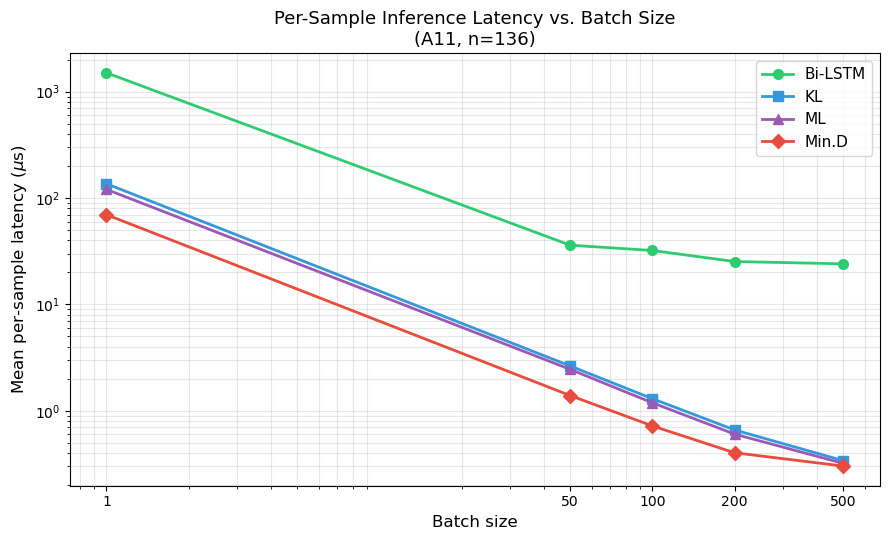

Plot saved: ./inference_timing_results/inference_latency_vs_batch.png


In [14]:
# =============================================================================
# CELL 14: PLOT -- PER-SAMPLE LATENCY VS BATCH SIZE
# =============================================================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = {'Bi-LSTM': '#2ecc71', 'KL': '#3498db',
          'ML': '#9b59b6', 'Min.D': '#e74c3c'}
markers = {'Bi-LSTM': 'o', 'KL': 's', 'ML': '^', 'Min.D': 'D'}

for name in DECODERS:
    ys = [timing_results[name][B]['mean_per_sample_ms'] * 1000.0
          for B in BATCH_SIZES]
    ax.plot(BATCH_SIZES, ys, marker=markers[name], color=colors[name],
            lw=2, ms=7, label=name)

ax.set_xlabel('Batch size', fontsize=12)
ax.set_ylabel('Mean per-sample latency ($\\mu$s)', fontsize=12)
ax.set_title('Per-Sample Inference Latency vs. Batch Size\n'
             f'({ALPHABET_NAME}, n={SEQ_LENGTH})', fontsize=13)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(BATCH_SIZES)
ax.set_xticklabels([str(b) for b in BATCH_SIZES])
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=11)
plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, "inference_latency_vs_batch.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Plot saved: {plot_path}")

## Cell 15 — Save results & paper-ready summary

In [15]:
# =============================================================================
# CELL 15: SAVE RESULTS & PAPER-READY SUMMARY
# =============================================================================
def to_serializable(obj):
    if isinstance(obj, dict):
        return {str(k): to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj


payload = {
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'device':    str(device),
    'gpu_name':  torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU',
    'config': {
        'alphabet':      ALPHABET_NAME,
        'vocab_size':    VOCAB_SIZE,
        'seq_length':    SEQ_LENGTH,
        'batch_sizes':   BATCH_SIZES,
        'model':         MODEL_CONFIG,
        'timing':        TIMING_CONFIG,
        'seed':          SEED,
    },
    'timing_results': to_serializable(timing_results),
    'batching_speedup': to_serializable(speedup),
}

results_path = os.path.join(RESULTS_DIR, "inference_timing_results.json")
with open(results_path, 'w') as f:
    json.dump(payload, f, indent=4)
print(f"Results saved: {results_path}")

print("\n" + "=" * 70)
print(" PAPER-READY SUMMARY")
print("=" * 70)
lstm_b1   = timing_results['Bi-LSTM'][1]['mean_per_sample_ms']
lstm_b500 = timing_results['Bi-LSTM'][500]['mean_per_sample_ms']
print(f"\n1. Bi-LSTM per-sample latency: "
      f"{lstm_b1*1000:.2f} us (B=1) -> {lstm_b500*1000:.2f} us (B=500)")
print(f"   Batching speed-up: {speedup['Bi-LSTM'][500]:.0f}x")
print(f"\n2. Baselines gain comparatively little from batching:")
for name in ['KL', 'ML', 'Min.D']:
    print(f"   {name:>6}: {speedup[name][500]:.1f}x speed-up (B=1 -> B=500)")
print(f"\n3. Absolute throughput at B=500 is far above practical needs:")
for name in DECODERS:
    tp = timing_results[name][500]['throughput_symbols_s']
    print(f"   {name:>8}: {tp/1e6:.2f}M symbols/s")
print("\n   => Batch processing concentrates its benefit on the neural decoder")
print("      and renders the per-sample cost negligible in absolute terms.")
print("=" * 70)

Results saved: ./inference_timing_results/inference_timing_results.json

 PAPER-READY SUMMARY

1. Bi-LSTM per-sample latency: 1504.22 us (B=1) -> 24.08 us (B=500)
   Batching speed-up: 62x

2. Baselines gain comparatively little from batching:
       KL: 400.5x speed-up (B=1 -> B=500)
       ML: 376.0x speed-up (B=1 -> B=500)
    Min.D: 230.5x speed-up (B=1 -> B=500)

3. Absolute throughput at B=500 is far above practical needs:
    Bi-LSTM: 5.65M symbols/s
         KL: 399.59M symbols/s
         ML: 424.03M symbols/s
      Min.D: 449.33M symbols/s

   => Batch processing concentrates its benefit on the neural decoder
      and renders the per-sample cost negligible in absolute terms.
